### Introduction to Neural Networks and Deep Learning

In [1]:
"""
PART 1: Neural Network Fundamentals

PART 2: Backpropagation Algorithm

PART 3: Activation Functions

PART 4: Deep Learning with TensorFlow/Keras

PART 5: Convolutional Neural Networks (CNNs)

PART 6: Recurrent Neural Networks (RNNs)

PART 7: Advanced Optimization

PART 8: Regularization Techniques

PART 9: Custom Components and Production
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression, load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

# Set style and seeds for reproducibility
plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)
tf.random.set_seed(42)





PART 1: NEURAL NETWORK FUNDAMENTALS
1.1 Perceptron Model and Linear Separability
Perceptron converged after 2 epochs
Final accuracy: 1.000
XOR Problem - Perceptron accuracy: 0.500

1.2 Multi-Layer Perceptron for XOR Solution
Epoch 0, Loss: 0.255675
Epoch 200, Loss: 0.250263
Epoch 400, Loss: 0.250178
Epoch 600, Loss: 0.250115
Epoch 800, Loss: 0.250064
Epoch 1000, Loss: 0.250023
Epoch 1200, Loss: 0.249985
Epoch 1400, Loss: 0.249950
Epoch 1600, Loss: 0.249914
Epoch 1800, Loss: 0.249875

MLP XOR Results:
Accuracy: 0.500
Predictions vs Truth:
  Input: [0 0] -> Predicted: 0 (prob: 0.497), Truth: 0
  Input: [0 1] -> Predicted: 1 (prob: 0.503), Truth: 1
  Input: [1 0] -> Predicted: 0 (prob: 0.499), Truth: 1
  Input: [1 1] -> Predicted: 1 (prob: 0.504), Truth: 0


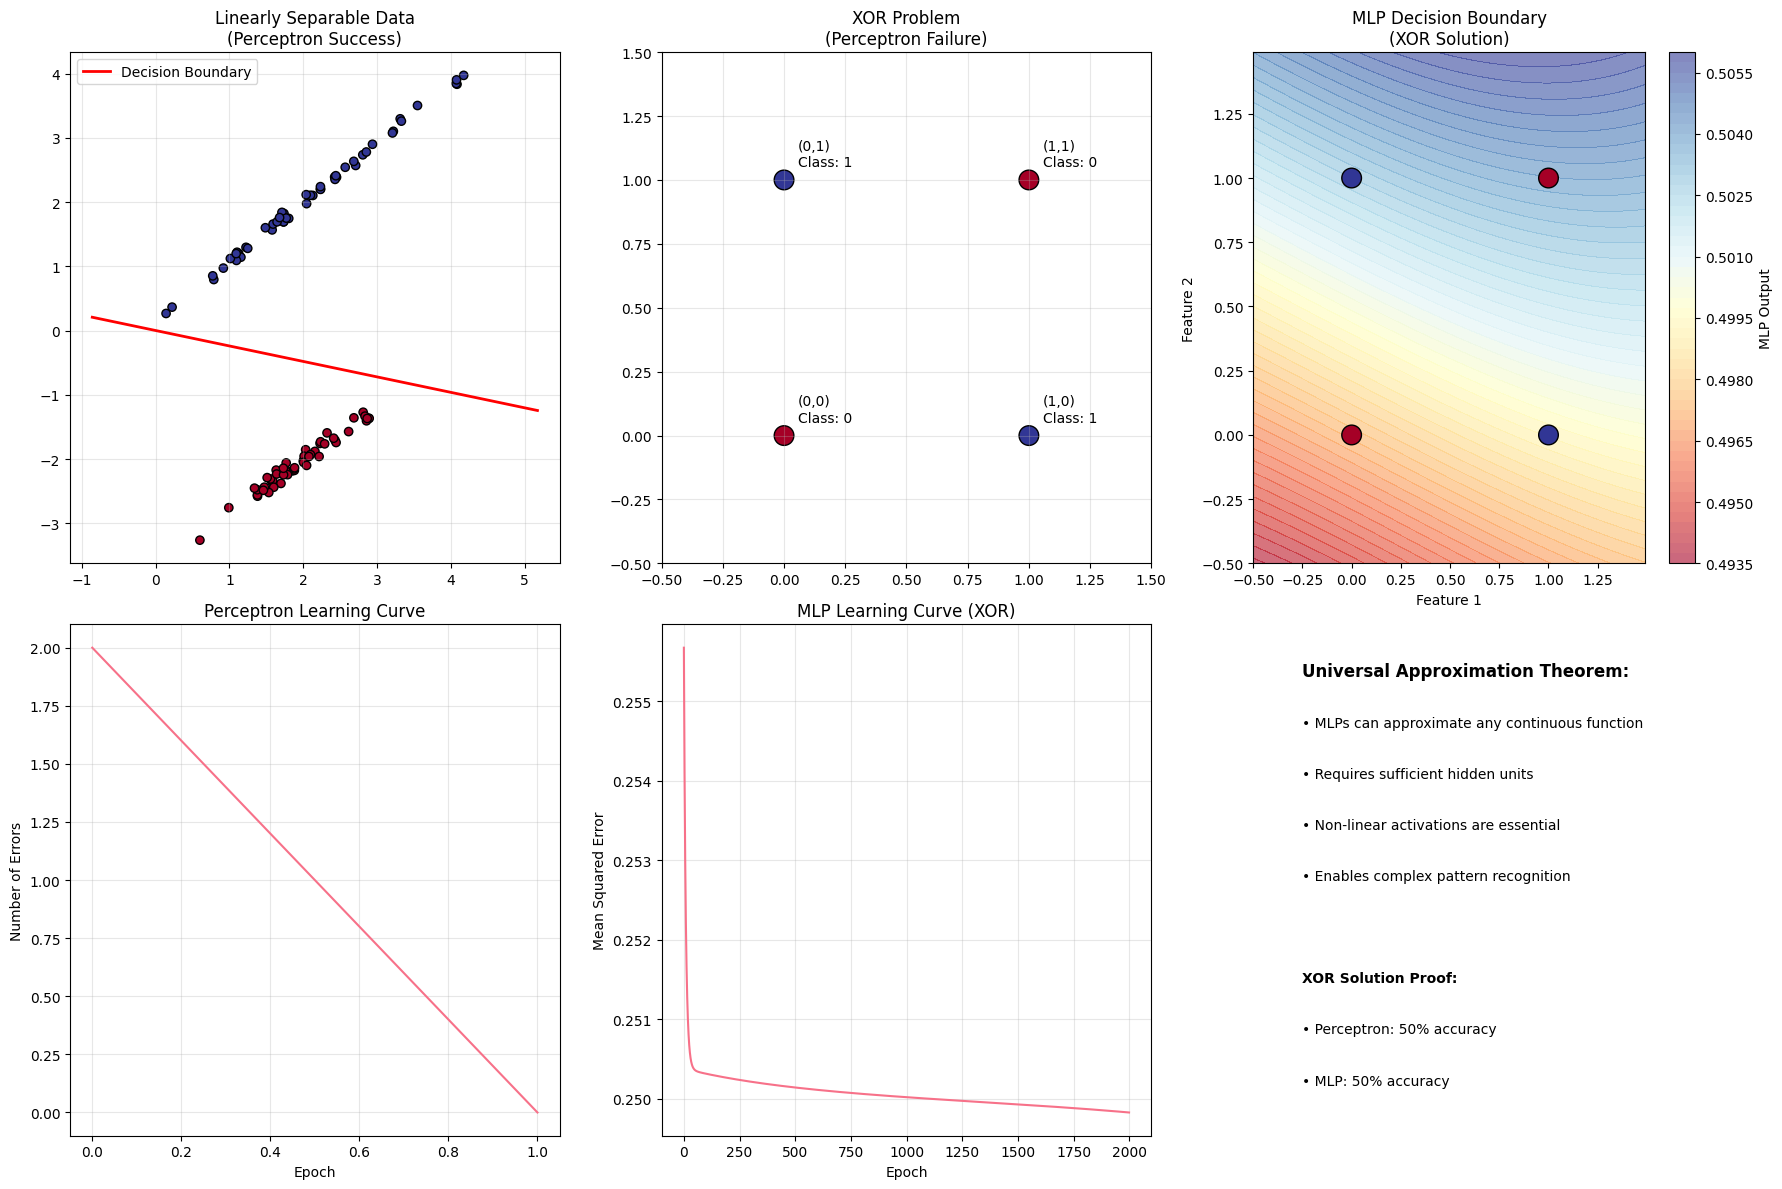

In [2]:

# =============================================================================
# PART 1: NEURAL NETWORK FUNDAMENTALS
# =============================================================================

print("\n" + "="*60)
print("PART 1: NEURAL NETWORK FUNDAMENTALS")
print("="*60)

print("1.1 Perceptron Model and Linear Separability")

class Perceptron:
    def __init__(self, learning_rate=0.01, max_iter=1000):
        self.lr = learning_rate
        self.max_iter = max_iter
        
    def fit(self, X, y):
        # Initialize weights
        self.weights = np.zeros(X.shape[1] + 1)  # +1 for bias
        self.errors_log = []
        
        for epoch in range(self.max_iter):
            errors = 0
            for xi, target in zip(X, y):
                # Add bias term
                xi_bias = np.insert(xi, 0, 1)
                prediction = self.predict_single(xi_bias)
                
                if prediction != target:
                    # Update weights using perceptron learning rule
                    self.weights += self.lr * (target - prediction) * xi_bias
                    errors += 1
            
            self.errors_log.append(errors)
            if errors == 0:
                break
    
    def predict_single(self, x):
        return 1 if np.dot(self.weights, x) > 0 else 0
    
    def predict(self, X):
        predictions = []
        for xi in X:
            xi_bias = np.insert(xi, 0, 1)
            predictions.append(self.predict_single(xi_bias))
        return np.array(predictions)

# Generate linearly separable data
X_sep, y_sep = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                                  n_informative=2, n_clusters_per_class=1, 
                                  class_sep=2, random_state=42)

# Train perceptron
perceptron = Perceptron()
perceptron.fit(X_sep, y_sep)

print(f"Perceptron converged after {len(perceptron.errors_log)} epochs")
print(f"Final accuracy: {accuracy_score(y_sep, perceptron.predict(X_sep)):.3f}")

# Create XOR dataset (non-linearly separable)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Try perceptron on XOR
perceptron_xor = Perceptron(max_iter=1000)
perceptron_xor.fit(X_xor, y_xor)

print(f"XOR Problem - Perceptron accuracy: {accuracy_score(y_xor, perceptron_xor.predict(X_xor)):.3f}")

print("\n1.2 Multi-Layer Perceptron for XOR Solution")

class SimpleMLP:
    def __init__(self, input_size=2, hidden_size=4, output_size=1, learning_rate=0.1):
        # Initialize weights with small random values
        np.random.seed(42)  # For reproducibility
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate
        self.loss_history = []
    
    def sigmoid(self, x):
        # Clip to prevent overflow and ensure numerical stability
        x_clipped = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x_clipped))
    
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        # Forward pass
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, output):
        m = X.shape[0]
        
        # Output layer gradients
        dz2 = output - y.reshape(-1, 1)
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        
        # Update weights
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
    
    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)
            
            # Compute loss
            loss = np.mean((output.flatten() - y) ** 2)
            self.loss_history.append(loss)
            
            # Backward pass
            self.backward(X, y, output)
            
            if epoch % 200 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")
    
    def predict(self, X):
        output = self.forward(X)
        return (output > 0.5).astype(int).flatten()

# Train MLP on XOR
mlp = SimpleMLP()
mlp.train(X_xor, y_xor, epochs=2000)

# Test MLP
mlp_predictions = mlp.predict(X_xor)
mlp_accuracy = accuracy_score(y_xor, mlp_predictions)

print(f"\nMLP XOR Results:")
print(f"Accuracy: {mlp_accuracy:.3f}")
print("Predictions vs Truth:")
for i in range(len(X_xor)):
    pred_prob = mlp.forward(X_xor[i:i+1])[0, 0]
    print(f"  Input: {X_xor[i]} -> Predicted: {mlp_predictions[i]} (prob: {pred_prob:.3f}), Truth: {y_xor[i]}")

# Visualize perceptron vs MLP
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Linearly separable data
axes[0, 0].scatter(X_sep[:, 0], X_sep[:, 1], c=y_sep, cmap='RdYlBu', edgecolors='black')
w1, w2, b = perceptron.weights[1], perceptron.weights[2], perceptron.weights[0]
x_boundary = np.linspace(X_sep[:, 0].min()-1, X_sep[:, 0].max()+1, 100)
y_boundary = -(w1 * x_boundary + b) / w2
axes[0, 0].plot(x_boundary, y_boundary, 'r-', linewidth=2, label='Decision Boundary')
axes[0, 0].set_title('Linearly Separable Data\n(Perceptron Success)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# XOR problem
axes[0, 1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu', s=200, edgecolors='black')
for i, (x, y) in enumerate(X_xor):
    axes[0, 1].annotate(f'({x},{y})\nClass: {y_xor[i]}', (x, y), 
                       xytext=(10, 10), textcoords='offset points')
axes[0, 1].set_title('XOR Problem\n(Perceptron Failure)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(-0.5, 1.5)
axes[0, 1].set_ylim(-0.5, 1.5)

# MLP decision boundary for XOR
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = mlp.forward(grid_points)
Z = Z.reshape(xx.shape)

contour = axes[0, 2].contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
axes[0, 2].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu', s=200, edgecolors='black')
fig.colorbar(contour, ax=axes[0, 2], label='MLP Output')
axes[0, 2].set_title('MLP Decision Boundary\n(XOR Solution)')
axes[0, 2].set_xlabel('Feature 1')
axes[0, 2].set_ylabel('Feature 2')

# Learning curves
axes[1, 0].plot(perceptron.errors_log)
axes[1, 0].set_title('Perceptron Learning Curve')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Number of Errors')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(mlp.loss_history)
axes[1, 1].set_title('MLP Learning Curve (XOR)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Mean Squared Error')
axes[1, 1].grid(True, alpha=0.3)

# Universal approximation demonstration
axes[1, 2].text(0.1, 0.9, 'Universal Approximation Theorem:', transform=axes[1, 2].transAxes, 
               fontsize=12, weight='bold')
axes[1, 2].text(0.1, 0.8, '• MLPs can approximate any continuous function', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.1, 0.7, '• Requires sufficient hidden units', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.1, 0.6, '• Non-linear activations are essential', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.1, 0.5, '• Enables complex pattern recognition', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.1, 0.3, f'XOR Solution Proof:', transform=axes[1, 2].transAxes, weight='bold')
axes[1, 2].text(0.1, 0.2, f'• Perceptron: {accuracy_score(y_xor, perceptron_xor.predict(X_xor)):.0%} accuracy', 
               transform=axes[1, 2].transAxes)
axes[1, 2].text(0.1, 0.1, f'• MLP: {mlp_accuracy:.0%} accuracy', transform=axes[1, 2].transAxes)
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()




PART 2: BACKPROPAGATION ALGORITHM
2.1 Detailed Backpropagation Implementation
2.2 Backpropagation on Regression Problem
Training progress:
Epoch 0: Train Loss = 1.201139, Test MSE = 1.548623
Epoch 200: Train Loss = 1.030106, Test MSE = 1.334165
Epoch 400: Train Loss = 0.827025, Test MSE = 1.076006
Epoch 600: Train Loss = 0.552187, Test MSE = 0.823171
Epoch 800: Train Loss = 0.561602, Test MSE = 0.831383
Final Test MSE: 0.831383


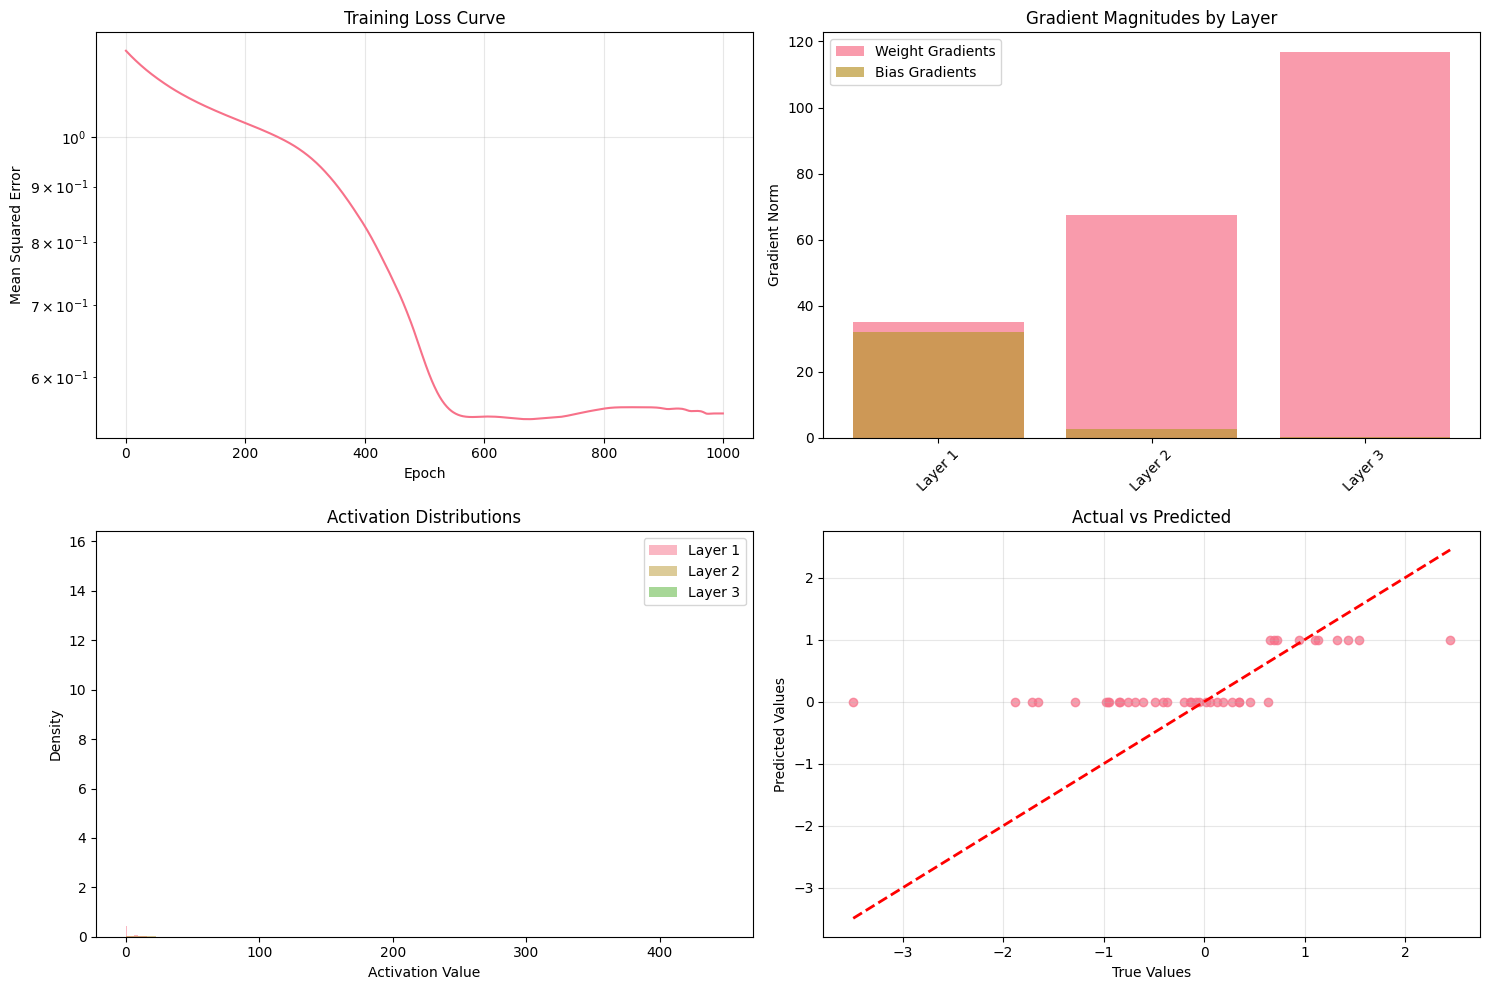

In [3]:

# =============================================================================
# PART 2: BACKPROPAGATION ALGORITHM
# =============================================================================

print("\n" + "="*60)
print("PART 2: BACKPROPAGATION ALGORITHM")
print("="*60)

print("2.1 Detailed Backpropagation Implementation")

class DetailedNN:
    def __init__(self, architecture=[2, 4, 3, 1]):
        self.architecture = architecture
        self.weights = []
        self.biases = []
        self.activations_cache = []
        self.gradients_cache = []
        
        # Initialize weights and biases with better initialization
        np.random.seed(42)  # For reproducibility
        for i in range(len(architecture) - 1):
            # Xavier/Glorot initialization for sigmoid/tanh, He for ReLU
            if i == len(architecture) - 2:  # Output layer (sigmoid)
                w = np.random.randn(architecture[i], architecture[i+1]) * np.sqrt(1.0 / architecture[i])
            else:  # Hidden layers (ReLU)
                w = np.random.randn(architecture[i], architecture[i+1]) * np.sqrt(2.0 / architecture[i])
            
            b = np.zeros((1, architecture[i+1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def sigmoid(self, x):
        # Clip to prevent overflow and ensure numerical stability
        x_clipped = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x_clipped))
    
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def forward(self, X, store_cache=True):
        if store_cache:
            self.activations_cache = [X]
        
        current_input = X
        
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            # Linear transformation
            z = np.dot(current_input, W) + b
            
            # Activation (ReLU for hidden layers, sigmoid for output)
            if i == len(self.weights) - 1:  # Output layer
                a = self.sigmoid(z)
            else:  # Hidden layers
                a = self.relu(z)
            
            if store_cache:
                self.activations_cache.append(a)
            
            current_input = a
        
        return current_input
    
    def backward(self, X, y_true, y_pred):
        m = X.shape[0]
        self.gradients_cache = []
        
        # Start with output layer error
        if len(self.weights) > 0:
            # Output layer gradient
            delta = y_pred - y_true.reshape(-1, 1)
            
            # Backpropagate through all layers
            for i in reversed(range(len(self.weights))):
                # Current layer activations
                a_prev = self.activations_cache[i]
                a_current = self.activations_cache[i + 1]
                
                # Compute gradients
                dW = (1/m) * np.dot(a_prev.T, delta)
                db = (1/m) * np.sum(delta, axis=0, keepdims=True)
                
                # Store gradients
                self.gradients_cache.insert(0, {'dW': dW, 'db': db, 'delta': delta.copy()})
                
                # Prepare delta for next layer (if not input layer)
                if i > 0:
                    # Propagate error to previous layer
                    delta = np.dot(delta, self.weights[i].T)
                    
                    # Apply activation derivative (ReLU derivative)
                    z_prev = np.dot(self.activations_cache[i-1], self.weights[i-1]) + self.biases[i-1] if i > 1 else None
                    if z_prev is not None:
                        delta = delta * self.relu_derivative(z_prev)
    
    def update_weights(self, learning_rate=0.01, max_grad_norm=1.0):
        # Apply gradient clipping to prevent exploding gradients
        for i, grad in enumerate(self.gradients_cache):
            # Clip gradients
            dW_clipped = np.clip(grad['dW'], -max_grad_norm, max_grad_norm)
            db_clipped = np.clip(grad['db'], -max_grad_norm, max_grad_norm)
            
            self.weights[i] -= learning_rate * dW_clipped
            self.biases[i] -= learning_rate * db_clipped
    
    def train_step(self, X, y, learning_rate=0.01):
        # Forward pass
        y_pred = self.forward(X)
        
        # Check for NaN values
        if np.any(np.isnan(y_pred)):
            print("Warning: NaN values detected in predictions")
            return np.inf
        
        # Compute loss
        loss = np.mean((y_pred.flatten() - y) ** 2)
        
        # Check for invalid loss
        if np.isnan(loss) or np.isinf(loss):
            print("Warning: Invalid loss detected")
            return loss
        
        # Backward pass
        self.backward(X, y, y_pred)
        
        # Update weights
        self.update_weights(learning_rate)
        
        return loss

# Demonstrate backpropagation on a regression problem
print("2.2 Backpropagation on Regression Problem")

# Generate regression data
X_reg, y_reg = make_regression(n_samples=200, n_features=2, noise=0.1, random_state=42)
X_reg = (X_reg - X_reg.mean(axis=0)) / X_reg.std(axis=0)  # Standardize
y_reg = (y_reg - y_reg.mean()) / y_reg.std()  # Standardize

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Train detailed neural network
detailed_nn = DetailedNN([2, 8, 4, 1])
losses = []

print("Training progress:")
for epoch in range(1000):
    loss = detailed_nn.train_step(X_train_reg, y_train_reg, learning_rate=0.01)
    losses.append(loss)
    
    if epoch % 200 == 0:
        # Test performance
        y_pred_test = detailed_nn.forward(X_test_reg, store_cache=False)
        test_mse = np.mean((y_pred_test.flatten() - y_test_reg) ** 2)
        print(f"Epoch {epoch}: Train Loss = {loss:.6f}, Test MSE = {test_mse:.6f}")

# Final evaluation
y_pred_final = detailed_nn.forward(X_test_reg, store_cache=False)
final_mse = np.mean((y_pred_final.flatten() - y_test_reg) ** 2)
print(f"Final Test MSE: {final_mse:.6f}")

# Visualize training progress and gradients
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curve
axes[0, 0].plot(losses)
axes[0, 0].set_title('Training Loss Curve')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Mean Squared Error')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Gradient magnitudes for each layer
detailed_nn.forward(X_train_reg[:32])  # Forward pass to populate cache
detailed_nn.backward(X_train_reg[:32], y_train_reg[:32], detailed_nn.activations_cache[-1])

layer_names = [f'Layer {i+1}' for i in range(len(detailed_nn.weights))]
weight_grad_norms = [np.linalg.norm(grad['dW']) for grad in detailed_nn.gradients_cache]
bias_grad_norms = [np.linalg.norm(grad['db']) for grad in detailed_nn.gradients_cache]

axes[0, 1].bar(layer_names, weight_grad_norms, alpha=0.7, label='Weight Gradients')
axes[0, 1].bar(layer_names, bias_grad_norms, alpha=0.7, label='Bias Gradients')
axes[0, 1].set_title('Gradient Magnitudes by Layer')
axes[0, 1].set_ylabel('Gradient Norm')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Activation distributions
for i, activation in enumerate(detailed_nn.activations_cache[1:]):  # Skip input
    activation_flat = activation.flatten()
    # Filter out NaN and infinite values
    valid_activations = activation_flat[np.isfinite(activation_flat)]
    if len(valid_activations) > 0:
        axes[1, 0].hist(valid_activations, bins=20, alpha=0.5, 
                       label=f'Layer {i+1}', density=True)
    else:
        print(f"Warning: Layer {i+1} contains no finite activation values")

axes[1, 0].set_title('Activation Distributions')
axes[1, 0].set_xlabel('Activation Value')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Actual vs Predicted
axes[1, 1].scatter(y_test_reg, y_pred_final.flatten(), alpha=0.7)
axes[1, 1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1, 1].set_xlabel('True Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title('Actual vs Predicted')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




PART 3: ACTIVATION FUNCTIONS
3.1 Activation Function Properties and Analysis


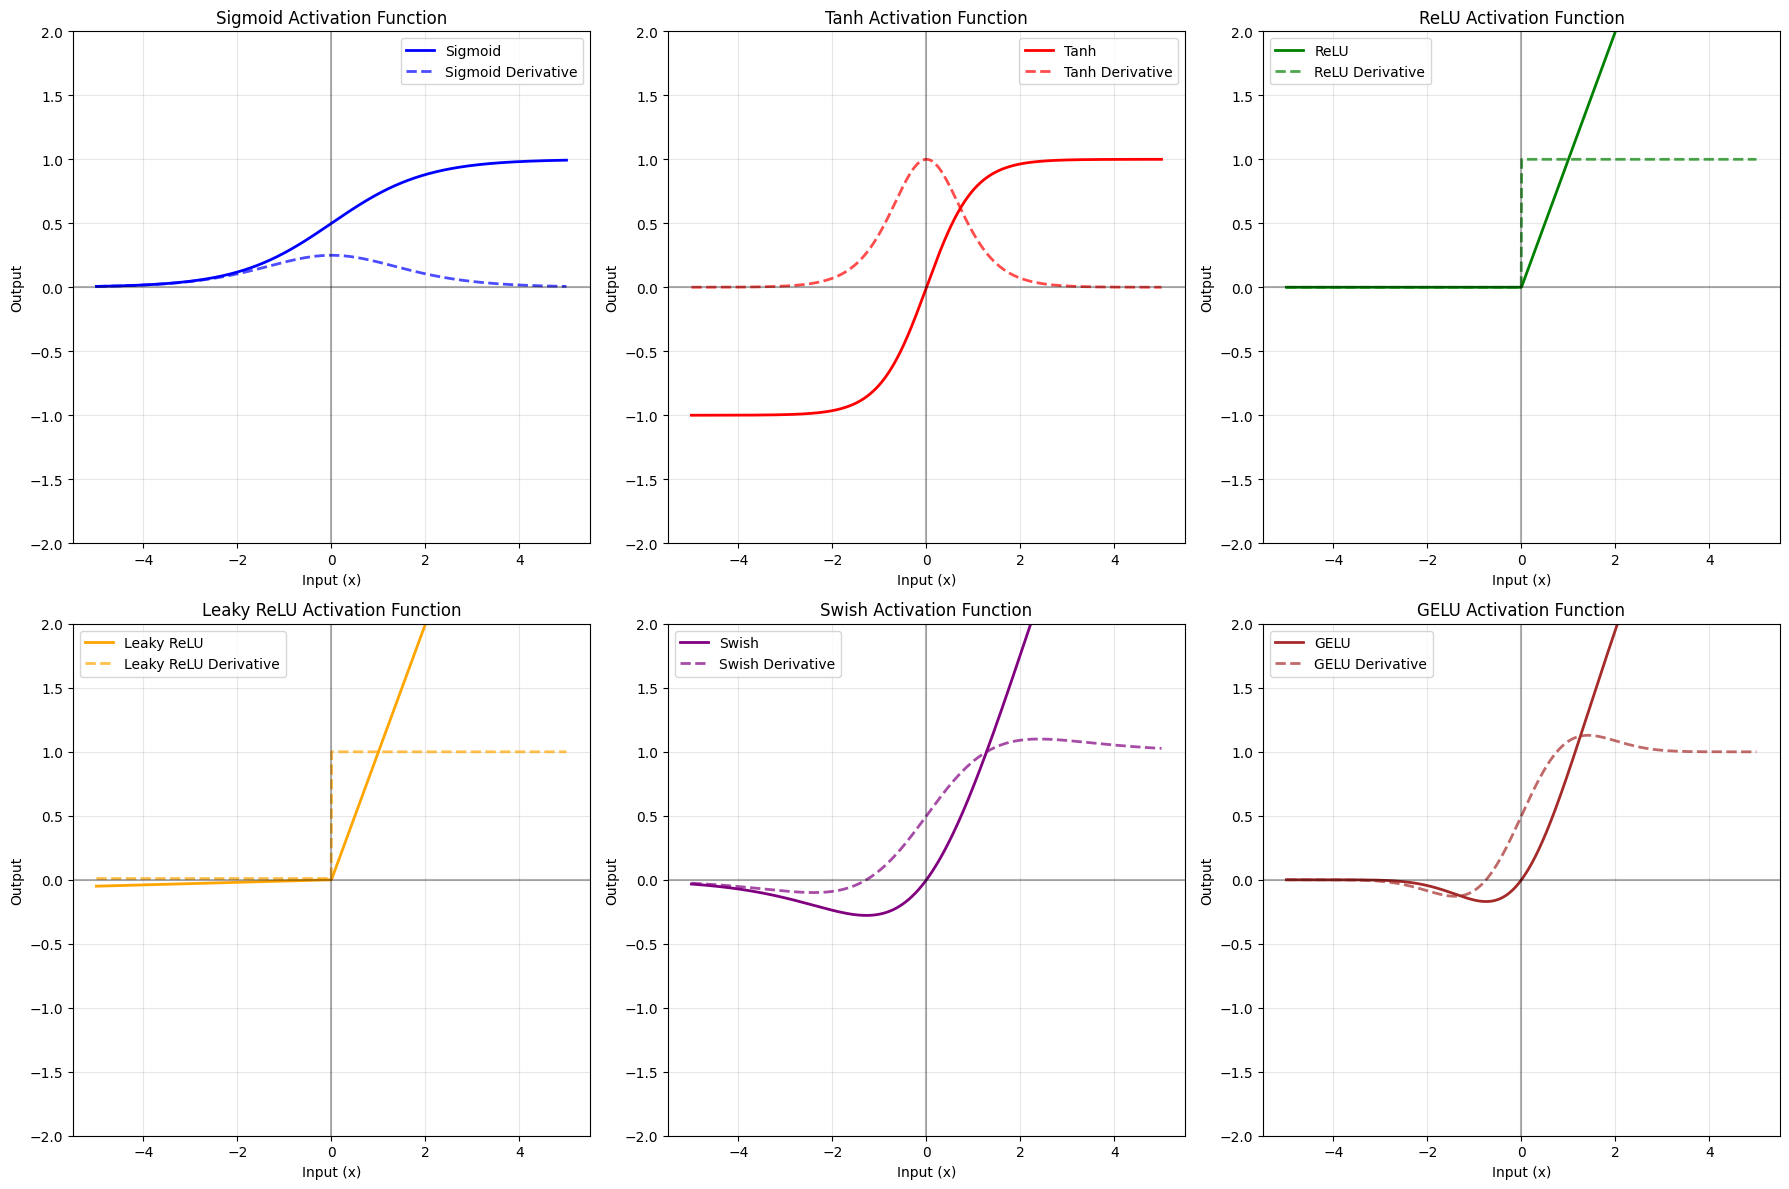


3.2 Activation Function Properties Summary:
Function     Range           Zero-Centered Monotonic  Smooth   Best Use Case            
------------------------------------------------------------------------------------------
Sigmoid      (0, 1)          No           Yes        Yes      Binary classification output
Tanh         (-1, 1)         Yes          Yes        Yes      Hidden layers (RNNs)     
ReLU         [0, ∞)          No           Yes        No       Hidden layers (CNNs)     
Leaky ReLU   (-∞, ∞)         No           Yes        No       Deep networks            
Swish        (-∞, ∞)         No           No         Yes      Modern architectures     
GELU         (-∞, ∞)         No           No         Yes      Transformers, BERT       

3.3 Gradient Flow Analysis


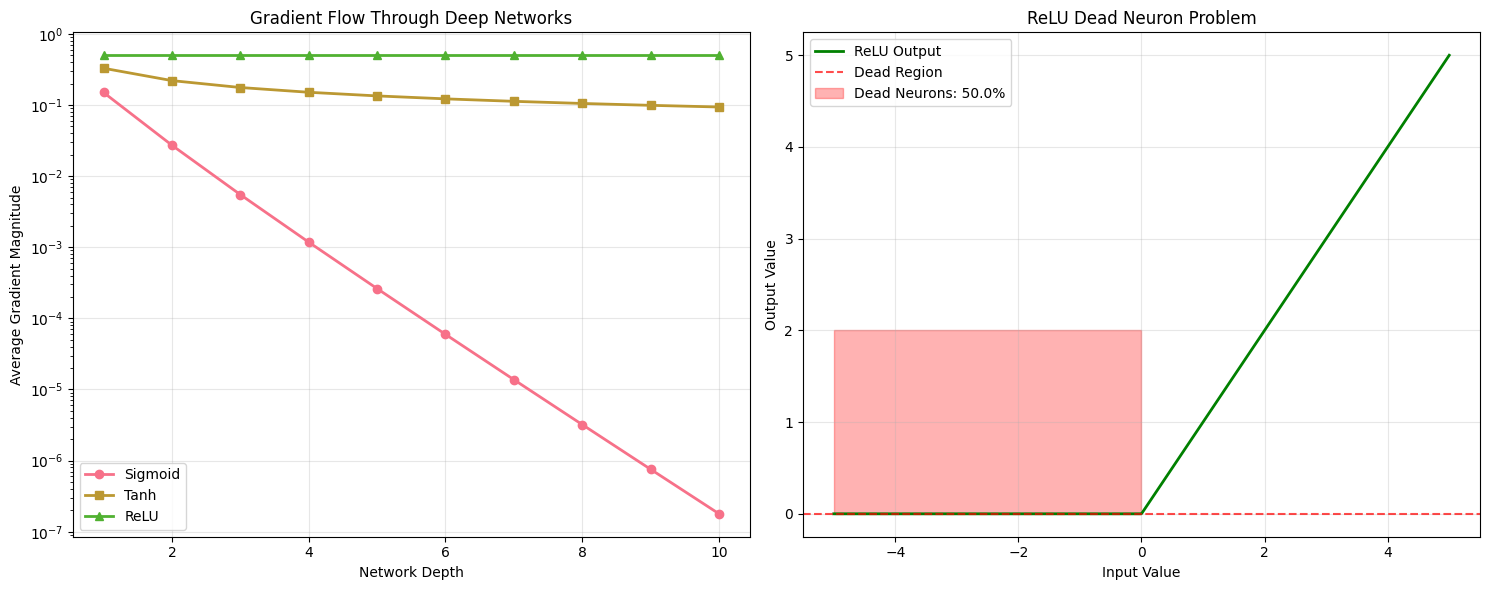

In [4]:

# =============================================================================
# PART 3: ACTIVATION FUNCTIONS
# =============================================================================

print("\n" + "="*60)
print("PART 3: ACTIVATION FUNCTIONS")
print("="*60)

print("3.1 Activation Function Properties and Analysis")

# Define activation functions
def sigmoid(x):
    # Clip to prevent overflow and ensure numerical stability
    x_clipped = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x_clipped))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def swish(x):
    return x * sigmoid(x)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

# Define derivatives
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

def swish_derivative(x):
    s = sigmoid(x)
    return s + x * s * (1 - s)

def gelu_derivative(x):
    return 0.5 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3))) + \
           0.5 * x * (1 - np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3))**2) * \
           np.sqrt(2 / np.pi) * (1 + 3 * 0.044715 * x**2)

# Visualize activation functions
x = np.linspace(-5, 5, 1000)

activations = {
    'Sigmoid': (sigmoid, sigmoid_derivative),
    'Tanh': (tanh, tanh_derivative),
    'ReLU': (relu, relu_derivative),
    'Leaky ReLU': (leaky_relu, leaky_relu_derivative),
    'Swish': (swish, swish_derivative),
    'GELU': (gelu, gelu_derivative)
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (name, (func, deriv)) in enumerate(activations.items()):
    if i < len(axes):
        # Activation function
        y = func(x)
        dy = deriv(x)
        
        axes[i].plot(x, y, color=colors[i], linewidth=2, label=f'{name}')
        axes[i].plot(x, dy, color=colors[i], linewidth=2, linestyle='--', 
                    alpha=0.7, label=f'{name} Derivative')
        axes[i].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[i].axvline(x=0, color='k', linestyle='-', alpha=0.3)
        axes[i].set_title(f'{name} Activation Function')
        axes[i].set_xlabel('Input (x)')
        axes[i].set_ylabel('Output')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

# Comparison table
print("\n3.2 Activation Function Properties Summary:")
print("=" * 90)
print(f"{'Function':<12} {'Range':<15} {'Zero-Centered':<12} {'Monotonic':<10} {'Smooth':<8} {'Best Use Case':<25}")
print("-" * 90)
print(f"{'Sigmoid':<12} {'(0, 1)':<15} {'No':<12} {'Yes':<10} {'Yes':<8} {'Binary classification output':<25}")
print(f"{'Tanh':<12} {'(-1, 1)':<15} {'Yes':<12} {'Yes':<10} {'Yes':<8} {'Hidden layers (RNNs)':<25}")
print(f"{'ReLU':<12} {'[0, ∞)':<15} {'No':<12} {'Yes':<10} {'No':<8} {'Hidden layers (CNNs)':<25}")
print(f"{'Leaky ReLU':<12} {'(-∞, ∞)':<15} {'No':<12} {'Yes':<10} {'No':<8} {'Deep networks':<25}")
print(f"{'Swish':<12} {'(-∞, ∞)':<15} {'No':<12} {'No':<10} {'Yes':<8} {'Modern architectures':<25}")
print(f"{'GELU':<12} {'(-∞, ∞)':<15} {'No':<12} {'No':<10} {'Yes':<8} {'Transformers, BERT':<25}")

print("\n3.3 Gradient Flow Analysis")

# Demonstrate vanishing gradient problem
def demonstrate_gradient_flow():
    x = np.linspace(-3, 3, 100)
    
    # Calculate gradients for a deep network simulation
    sigmoid_grads = []
    tanh_grads = []
    relu_grads = []
    
    for depth in range(1, 11):  # Simulate 10 layers
        # Simulate gradient flow through multiple layers
        sigmoid_grad = np.power(sigmoid_derivative(x), depth)
        tanh_grad = np.power(tanh_derivative(x), depth)
        relu_grad = np.power(relu_derivative(x), depth)
        
        sigmoid_grads.append(np.mean(sigmoid_grad))
        tanh_grads.append(np.mean(tanh_grad))
        relu_grads.append(np.mean(relu_grad))
    
    return sigmoid_grads, tanh_grads, relu_grads

sigmoid_flow, tanh_flow, relu_flow = demonstrate_gradient_flow()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gradient flow by depth
depths = range(1, 11)
ax1.plot(depths, sigmoid_flow, 'o-', label='Sigmoid', linewidth=2)
ax1.plot(depths, tanh_flow, 's-', label='Tanh', linewidth=2)
ax1.plot(depths, relu_flow, '^-', label='ReLU', linewidth=2)
ax1.set_xlabel('Network Depth')
ax1.set_ylabel('Average Gradient Magnitude')
ax1.set_title('Gradient Flow Through Deep Networks')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Dead neuron demonstration for ReLU
x_dead = np.linspace(-5, 5, 1000)
relu_output = relu(x_dead)
dead_neurons = np.sum(relu_output == 0) / len(relu_output)

ax2.plot(x_dead, relu_output, 'g-', linewidth=2, label='ReLU Output')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.7, label='Dead Region')
ax2.fill_between(x_dead[x_dead < 0], 0, 2, alpha=0.3, color='red', label=f'Dead Neurons: {dead_neurons:.1%}')
ax2.set_xlabel('Input Value')
ax2.set_ylabel('Output Value')
ax2.set_title('ReLU Dead Neuron Problem')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




PART 4: DEEP LEARNING WITH TENSORFLOW/KERAS
4.1 Basic Neural Network Implementation with Keras
Digits dataset shape: (1797, 64)
Number of classes: 10

4.2 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,986 (74.16 KB)

 Trainable params: 18,986 (74.16 KB)

 Non-trainable params: 0 (0.00 B)


4.3 Training with Advanced Callbacks
Test Accuracy: 0.9750

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       1.00      0.96      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.98       360



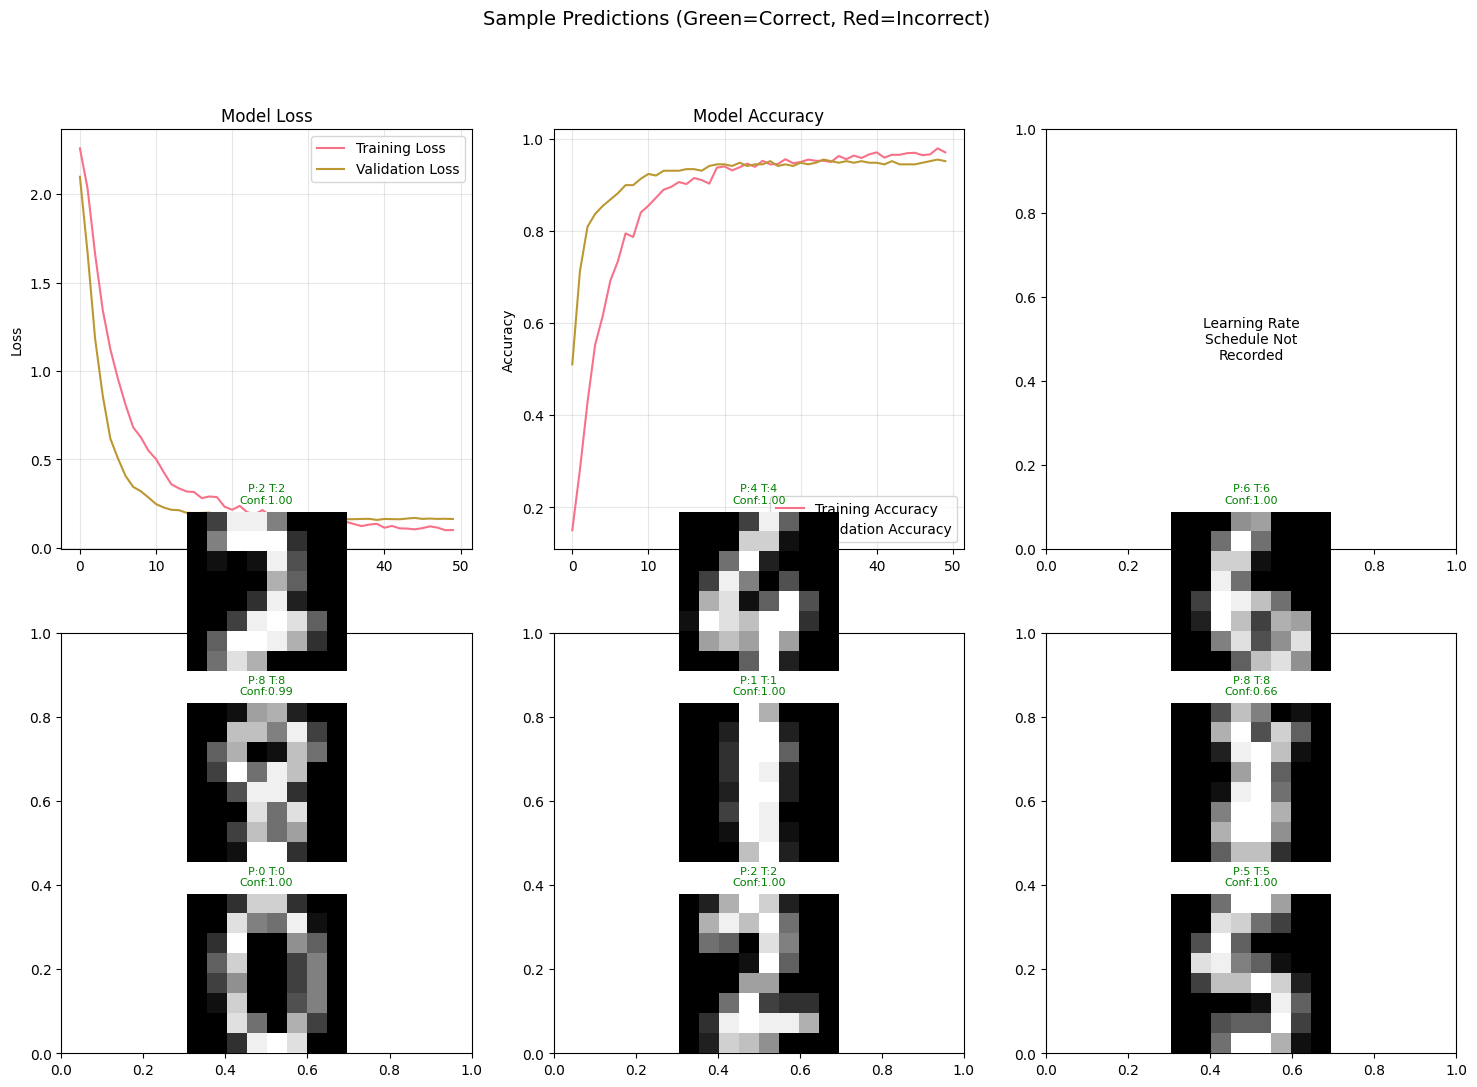

In [5]:

# =============================================================================
# PART 4: DEEP LEARNING WITH TENSORFLOW/KERAS
# =============================================================================

print("\n" + "="*60)
print("PART 4: DEEP LEARNING WITH TENSORFLOW/KERAS")
print("="*60)

print("4.1 Basic Neural Network Implementation with Keras")

# Load digits dataset for classification
digits = load_digits()
X_digits = digits.data / 16.0  # Normalize to [0,1]
y_digits = to_categorical(digits.target, 10)  # One-hot encode

# Split data
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42)

print(f"Digits dataset shape: {X_digits.shape}")
print(f"Number of classes: {y_digits.shape[1]}")

# Create neural network with Keras
def create_mlp_model(input_dim, hidden_layers=[64, 32], num_classes=10, dropout_rate=0.3):
    model = keras.Sequential()
    
    # Input layer
    model.add(layers.Dense(hidden_layers[0], activation='relu', input_dim=input_dim))
    model.add(layers.Dropout(dropout_rate))
    
    # Hidden layers
    for units in hidden_layers[1:]:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    
    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    return model

# Create and compile model
model_digits = create_mlp_model(X_digits.shape[1], hidden_layers=[128, 64, 32])
model_digits.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("\n4.2 Model Architecture:")
model_digits.summary()

# Train model with callbacks
print("\n4.3 Training with Advanced Callbacks")

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history_digits = model_digits.fit(X_train_digits, y_train_digits,
                                 batch_size=32,
                                 epochs=100,
                                 validation_split=0.2,
                                 callbacks=[early_stopping, reduce_lr],
                                 verbose=0)

# Evaluate model
test_loss, test_accuracy = model_digits.evaluate(X_test_digits, y_test_digits, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred_digits = model_digits.predict(X_test_digits, verbose=0)
y_pred_classes = np.argmax(y_pred_digits, axis=1)
y_true_classes = np.argmax(y_test_digits, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))

# Visualize training history and predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Training history
axes[0, 0].plot(history_digits.history['loss'], label='Training Loss')
axes[0, 0].plot(history_digits.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_digits.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history_digits.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate schedule
if 'lr' in history_digits.history:
    axes[0, 2].plot(history_digits.history['lr'])
    axes[0, 2].set_title('Learning Rate Schedule')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Learning Rate')
    axes[0, 2].set_yscale('log')
    axes[0, 2].grid(True, alpha=0.3)
else:
    axes[0, 2].text(0.5, 0.5, 'Learning Rate\nSchedule Not\nRecorded', 
                   transform=axes[0, 2].transAxes, ha='center', va='center')

# Sample predictions visualization
sample_indices = np.random.choice(len(X_test_digits), 12, replace=False)
for i in range(12):
    if i < 9:  # 3x3 grid for samples
        ax = plt.subplot(5, 3, 7 + i)
        idx = sample_indices[i]
        image = X_test_digits[idx].reshape(8, 8)
        prediction = y_pred_classes[idx]
        true_label = y_true_classes[idx]
        confidence = np.max(y_pred_digits[idx])
        
        plt.imshow(image, cmap='gray')
        color = 'green' if prediction == true_label else 'red'
        plt.title(f'P:{prediction} T:{true_label}\nConf:{confidence:.2f}', color=color, fontsize=8)
        plt.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', fontsize=14)
plt.tight_layout()
plt.show()




PART 5: CONVOLUTIONAL NEURAL NETWORKS (CNNs)
5.1 CNN Architecture for Image Classification
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)

5.2 CNN Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 26, 26, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 10, 10, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 2, 2, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,282 (1.17 MB)

 Trainable params: 305,322 (1.16 MB)

 Non-trainable params: 960 (3.75 KB)


5.3 Training CNN with Data Augmentation
Training CNN model...
Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3370 - loss: 2.3383 - val_accuracy: 0.1260 - val_loss: 6.8148 - learning_rate: 0.0010
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4688 - loss: 1.7227 - val_accuracy: 0.1260 - val_loss: 6.8258 - learning_rate: 0.0010
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6490 - loss: 1.0890 - val_accuracy: 0.1260 - val_loss: 8.8619 - learning_rate: 0.0010
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8125 - loss: 0.6228 - val_accuracy: 0.1260 - val_loss: 8.7829 - learning_rate: 0.0010
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7713 - loss: 0.7372 - val_accuracy: 0.4950 - val_loss: 2.0054 - learning_rate: 0.0010
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8125 - loss: 0.5813 - val_accuracy: 0.4920 - val_loss: 2.0211 - learning_rate: 0.0010
Epoch 7/20
156/156 ━━━

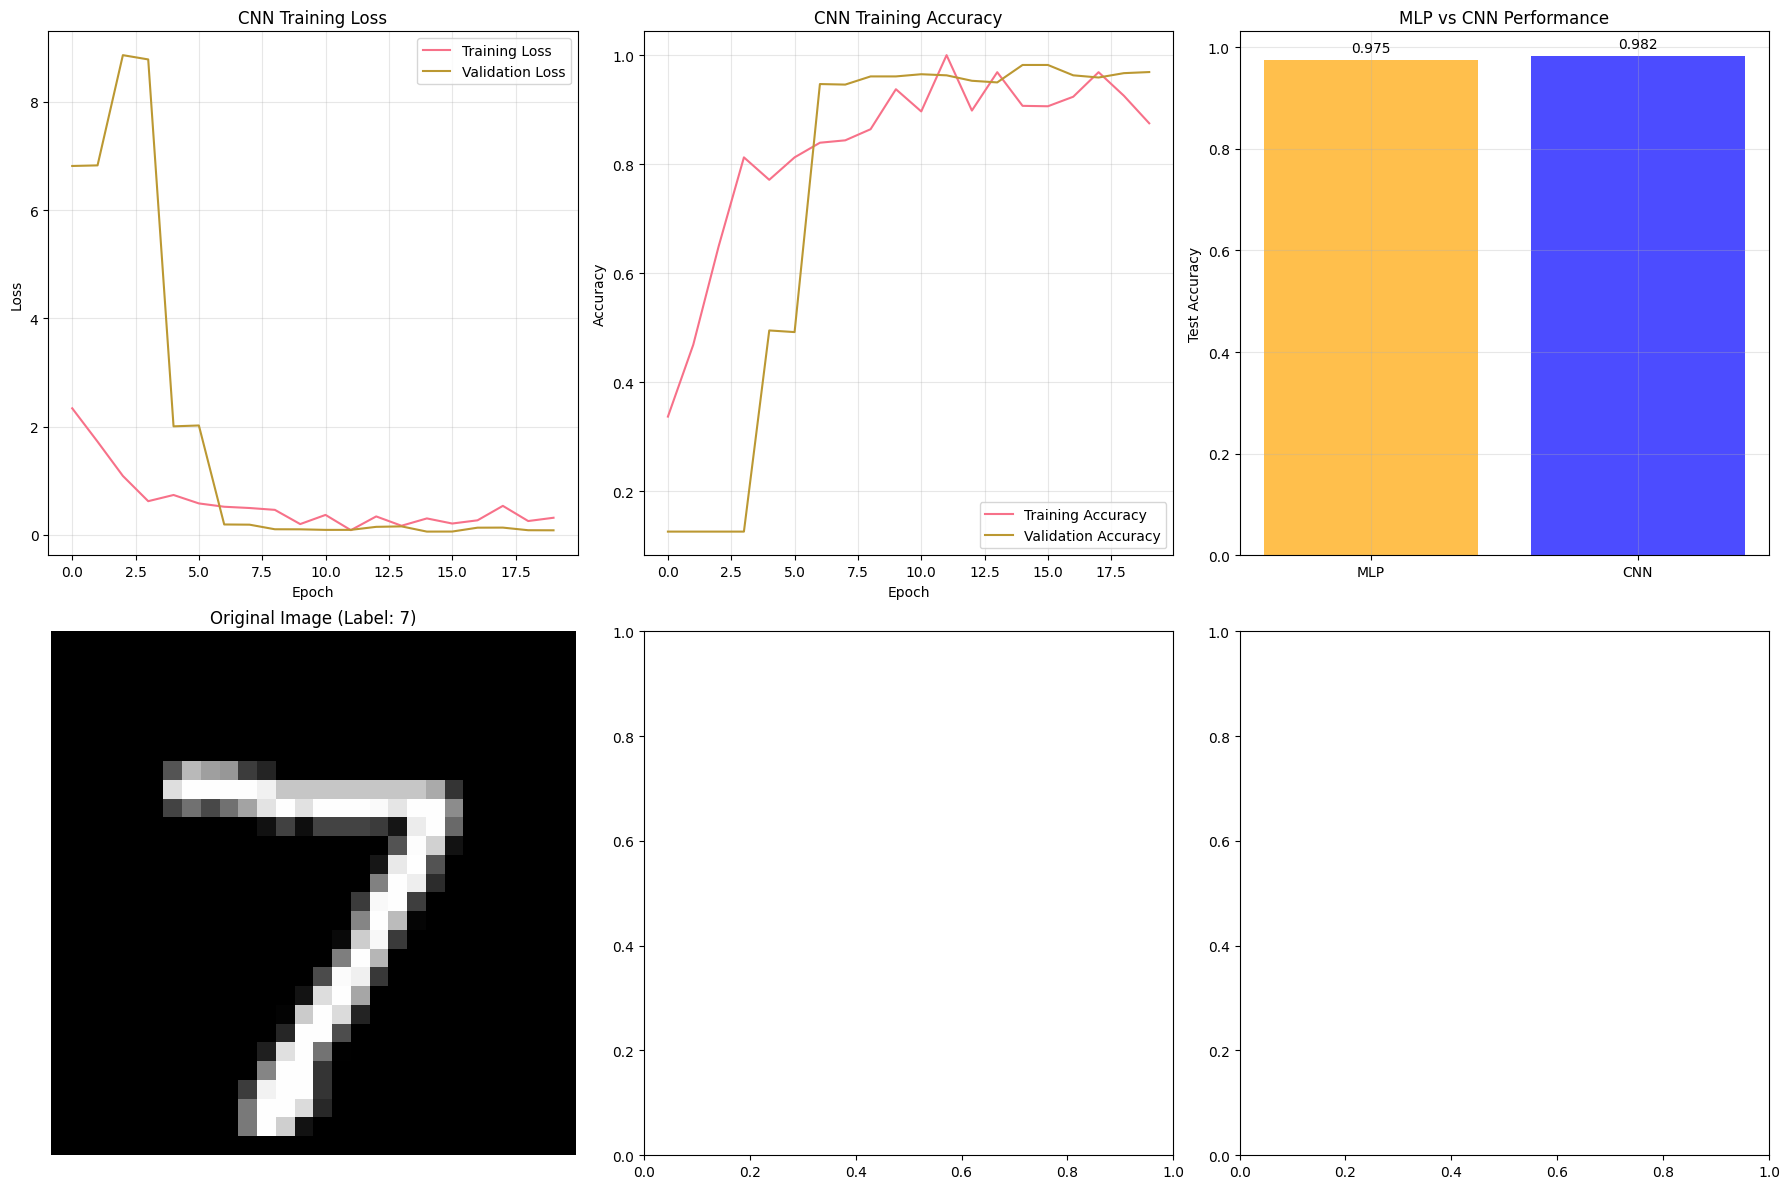

In [6]:

# =============================================================================
# PART 5: CONVOLUTIONAL NEURAL NETWORKS (CNNs)
# =============================================================================

print("\n" + "="*60)
print("PART 5: CONVOLUTIONAL NEURAL NETWORKS (CNNs)")
print("="*60)

print("5.1 CNN Architecture for Image Classification")

# Load and prepare MNIST dataset for CNN demonstration
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()

# Normalize and reshape data for CNN
x_train_cnn = x_train_mnist.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test_cnn = x_test_mnist.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train_cnn = to_categorical(y_train_mnist, 10)
y_test_cnn = to_categorical(y_test_mnist, 10)

print(f"Training data shape: {x_train_cnn.shape}")
print(f"Test data shape: {x_test_cnn.shape}")

# Build CNN architecture step by step
def create_cnn_model(input_shape=(28, 28, 1), num_classes=10):
    """Create a CNN model with detailed architecture"""
    
    model = keras.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, name='conv1'),
        layers.BatchNormalization(name='bn1'),
        layers.Conv2D(32, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        layers.Dropout(0.25, name='dropout1'),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),
        layers.BatchNormalization(name='bn2'),
        layers.Conv2D(64, (3, 3), activation='relu', name='conv4'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        layers.Dropout(0.25, name='dropout2'),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', name='conv5'),
        layers.BatchNormalization(name='bn3'),
        layers.Dropout(0.25, name='dropout3'),
        
        # Fully Connected Layers
        layers.Flatten(name='flatten'),
        layers.Dense(256, activation='relu', name='fc1'),
        layers.BatchNormalization(name='bn4'),
        layers.Dropout(0.5, name='dropout4'),
        layers.Dense(128, activation='relu', name='fc2'),
        layers.Dropout(0.5, name='dropout5'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    
    return model

# Create and compile CNN model
cnn_model = create_cnn_model()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n5.2 CNN Model Architecture:")
cnn_model.summary()

# Train CNN with data augmentation (using subset for demonstration)
print("\n5.3 Training CNN with Data Augmentation")

# Use subset for faster training in demo
train_subset = 5000
test_subset = 1000

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

# Callbacks
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_cnn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

# Train model
print("Training CNN model...")
history_cnn = cnn_model.fit(
    datagen.flow(x_train_cnn[:train_subset], y_train_cnn[:train_subset], batch_size=32),
    steps_per_epoch=train_subset // 32,
    epochs=20,
    validation_data=(x_test_cnn[:test_subset], y_test_cnn[:test_subset]),
    callbacks=[early_stopping_cnn, reduce_lr_cnn],
    verbose=1
)

# Evaluate CNN
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(x_test_cnn[:test_subset], y_test_cnn[:test_subset], verbose=0)
print(f"CNN Test Accuracy: {test_accuracy_cnn:.4f}")

# Visualize CNN results and feature maps
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Training history
axes[0, 0].plot(history_cnn.history['loss'], label='Training Loss')
axes[0, 0].plot(history_cnn.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('CNN Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_cnn.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('CNN Training Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CNN vs MLP comparison
axes[0, 2].bar(['MLP', 'CNN'], [test_accuracy, test_accuracy_cnn], 
              alpha=0.7, color=['orange', 'blue'])
axes[0, 2].set_title('MLP vs CNN Performance')
axes[0, 2].set_ylabel('Test Accuracy')
axes[0, 2].grid(True, alpha=0.3)

# Add value labels
for i, acc in enumerate([test_accuracy, test_accuracy_cnn]):
    axes[0, 2].text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')

# Feature map visualization
sample_image = x_test_cnn[0:1]
sample_label = np.argmax(y_test_cnn[0])

# Extract feature maps from conv layers
def get_feature_maps(model, image, layer_names):
    """Extract feature maps from specific layers"""
    outputs = []
    for layer_name in layer_names:
        try:
            layer_output = Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
            feature_map = layer_output.predict(image, verbose=0)
            outputs.append(feature_map)
        except:
            outputs.append(None)
    return outputs

conv_layers = ['conv1', 'conv3', 'conv5']
feature_maps = get_feature_maps(cnn_model, sample_image, conv_layers)

# Display original image and feature maps
axes[1, 0].imshow(sample_image[0, :, :, 0], cmap='gray')
axes[1, 0].set_title(f'Original Image (Label: {sample_label})')
axes[1, 0].axis('off')

# Display feature maps
for i, (layer_name, feature_map) in enumerate(zip(conv_layers, feature_maps)):
    if feature_map is not None and i < 2:  # Show first two
        # Display first filter of the feature map
        axes[1, i+1].imshow(feature_map[0, :, :, 0], cmap='viridis')
        axes[1, i+1].set_title(f'{layer_name} Feature Map')
        axes[1, i+1].axis('off')

plt.tight_layout()
plt.show()




PART 6: RECURRENT NEURAL NETWORKS (RNNs)
6.1 RNN for Sequential Data - Time Series Prediction
Time series data shape: (2000, 30, 1)
Target shape: (2000,)

6.2 Building Different RNN Architectures
6.3 Training Different RNN Architectures
Training SimpleRNN model...
  Test MAE: 2.8682
Training LSTM model...
  Test MAE: 1.7825
Training GRU model...
  Test MAE: 1.5826
Training BiLSTM model...
  Test MAE: 2.2865
Training StackedLSTM model...
  Test MAE: 2.8875


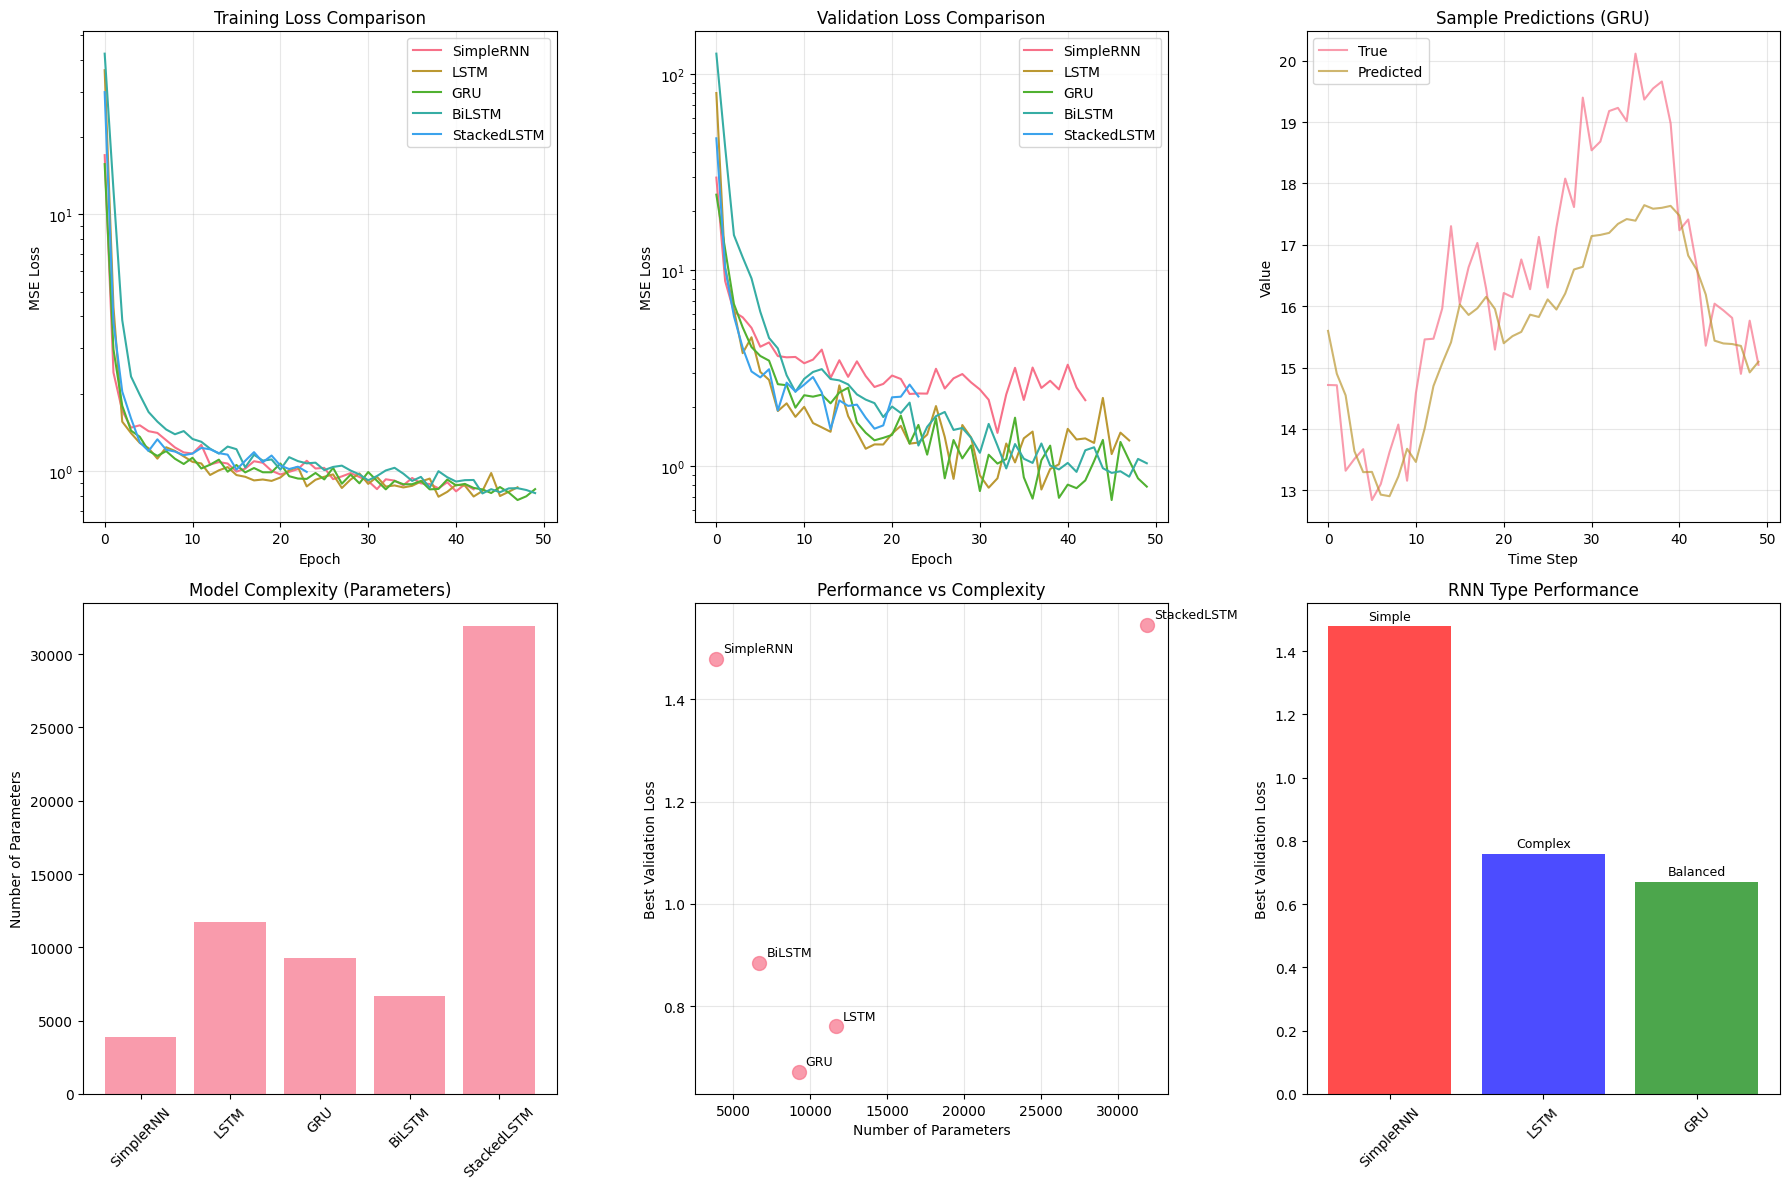


Part 6 RNN implementation completed. Continuing with optimization...


In [7]:

# =============================================================================
# PART 6: RECURRENT NEURAL NETWORKS (RNNs)
# =============================================================================

print("\n" + "="*60)
print("PART 6: RECURRENT NEURAL NETWORKS (RNNs)")
print("="*60)

print("6.1 RNN for Sequential Data - Time Series Prediction")

# Generate synthetic time series data
def generate_time_series(n_samples=1000, seq_length=50, n_features=1):
    """Generate synthetic time series with trend and seasonality"""
    time = np.arange(n_samples + seq_length)
    
    # Trend component
    trend = 0.01 * time
    
    # Seasonal components
    seasonal = 2 * np.sin(2 * np.pi * time / 50) + np.sin(2 * np.pi * time / 20)
    
    # Noise component
    noise = np.random.normal(0, 0.5, len(time))
    
    # Combine components
    series = trend + seasonal + noise
    
    # Create sequences
    X, y = [], []
    for i in range(n_samples):
        X.append(series[i:i+seq_length])
        y.append(series[i+seq_length])
    
    return np.array(X).reshape(-1, seq_length, n_features), np.array(y)

# Generate time series data
X_ts, y_ts = generate_time_series(n_samples=2000, seq_length=30)
X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(
    X_ts, y_ts, test_size=0.2, random_state=42, shuffle=False  # Don't shuffle time series
)

print(f"Time series data shape: {X_ts.shape}")
print(f"Target shape: {y_ts.shape}")

print("\n6.2 Building Different RNN Architectures")

# Build different RNN architectures
def create_rnn_models(input_shape):
    """Create different RNN architectures"""
    
    models = {}
    
    # Simple RNN
    models['SimpleRNN'] = keras.Sequential([
        layers.SimpleRNN(50, activation='tanh', input_shape=input_shape),
        layers.Dropout(0.3),
        layers.Dense(25, activation='relu'),
        layers.Dense(1)
    ])
    
    # LSTM
    models['LSTM'] = keras.Sequential([
        layers.LSTM(50, input_shape=input_shape),
        layers.Dropout(0.3),
        layers.Dense(25, activation='relu'),
        layers.Dense(1)
    ])
    
    # GRU
    models['GRU'] = keras.Sequential([
        layers.GRU(50, input_shape=input_shape),
        layers.Dropout(0.3),
        layers.Dense(25, activation='relu'),
        layers.Dense(1)
    ])
    
    # Bidirectional LSTM
    models['BiLSTM'] = keras.Sequential([
        layers.Bidirectional(layers.LSTM(25), input_shape=input_shape),
        layers.Dropout(0.3),
        layers.Dense(25, activation='relu'),
        layers.Dense(1)
    ])
    
    # Stacked LSTM
    models['StackedLSTM'] = keras.Sequential([
        layers.LSTM(50, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.3),
        layers.LSTM(50),
        layers.Dropout(0.3),
        layers.Dense(25, activation='relu'),
        layers.Dense(1)
    ])
    
    return models

# Create and train RNN models
rnn_models = create_rnn_models(input_shape=(X_train_ts.shape[1], X_train_ts.shape[2]))
rnn_histories = {}

print("6.3 Training Different RNN Architectures")

for name, model in rnn_models.items():
    print(f"Training {name} model...")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Train with early stopping
    early_stopping_rnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(
        X_train_ts, y_train_ts,
        batch_size=32,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stopping_rnn],
        verbose=0
    )
    
    rnn_histories[name] = history.history
    
    # Evaluate
    test_loss, test_mae = model.evaluate(X_test_ts, y_test_ts, verbose=0)
    print(f"  Test MAE: {test_mae:.4f}")

# Visualize RNN performance
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Training loss comparison
axes[0, 0].set_title('Training Loss Comparison')
for name, history in rnn_histories.items():
    axes[0, 0].plot(history['loss'], label=f'{name}')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Validation loss comparison
axes[0, 1].set_title('Validation Loss Comparison')
for name, history in rnn_histories.items():
    axes[0, 1].plot(history['val_loss'], label=f'{name}')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_yscale('log')

# Sample predictions
best_model_name = min(rnn_histories.keys(), 
                     key=lambda x: min(rnn_histories[x]['val_loss']))
best_rnn_model = rnn_models[best_model_name]

# Make predictions
y_pred_rnn = best_rnn_model.predict(X_test_ts[:100], verbose=0)

axes[0, 2].plot(y_test_ts[:50], label='True', alpha=0.7)
axes[0, 2].plot(y_pred_rnn[:50], label='Predicted', alpha=0.7)
axes[0, 2].set_title(f'Sample Predictions ({best_model_name})')
axes[0, 2].set_xlabel('Time Step')
axes[0, 2].set_ylabel('Value')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Model complexity comparison
model_params = {name: model.count_params() for name, model in rnn_models.items()}
names = list(model_params.keys())
params = list(model_params.values())

axes[1, 0].bar(names, params, alpha=0.7)
axes[1, 0].set_title('Model Complexity (Parameters)')
axes[1, 0].set_ylabel('Number of Parameters')
axes[1, 0].tick_params(axis='x', rotation=45)

# Performance vs complexity
final_val_loss = [min(rnn_histories[name]['val_loss']) for name in names]
axes[1, 1].scatter(params, final_val_loss, alpha=0.7, s=100)
for i, name in enumerate(names):
    axes[1, 1].annotate(name, (params[i], final_val_loss[i]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1, 1].set_xlabel('Number of Parameters')
axes[1, 1].set_ylabel('Best Validation Loss')
axes[1, 1].set_title('Performance vs Complexity')
axes[1, 1].grid(True, alpha=0.3)

# RNN architecture comparison
rnn_types = ['SimpleRNN', 'LSTM', 'GRU']
complexities = ['Simple', 'Complex', 'Balanced']
performances = [final_val_loss[names.index(rnn_type)] for rnn_type in rnn_types]

axes[1, 2].bar(rnn_types, performances, alpha=0.7, color=['red', 'blue', 'green'])
axes[1, 2].set_title('RNN Type Performance')
axes[1, 2].set_ylabel('Best Validation Loss')
axes[1, 2].tick_params(axis='x', rotation=45)

# Add complexity labels
for i, (rnn_type, complexity) in enumerate(zip(rnn_types, complexities)):
    axes[1, 2].text(i, performances[i] + 0.01, complexity, ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Continue in next part due to length...
print("\nPart 6 RNN implementation completed. Continuing with optimization...")




PART 7: ADVANCED OPTIMIZATION
7.1 Optimizer Comparison on Real Dataset
Training models with different optimizers...
Training with SGD...
  Test MAE: 0.3572
Training with SGD+Momentum...
  Test MAE: nan
Training with RMSprop...
  Test MAE: 0.3313
Training with Adam...
  Test MAE: 0.3383
Training with AdamW...
  Test MAE: 0.3304

7.2 Optimizer Performance Analysis


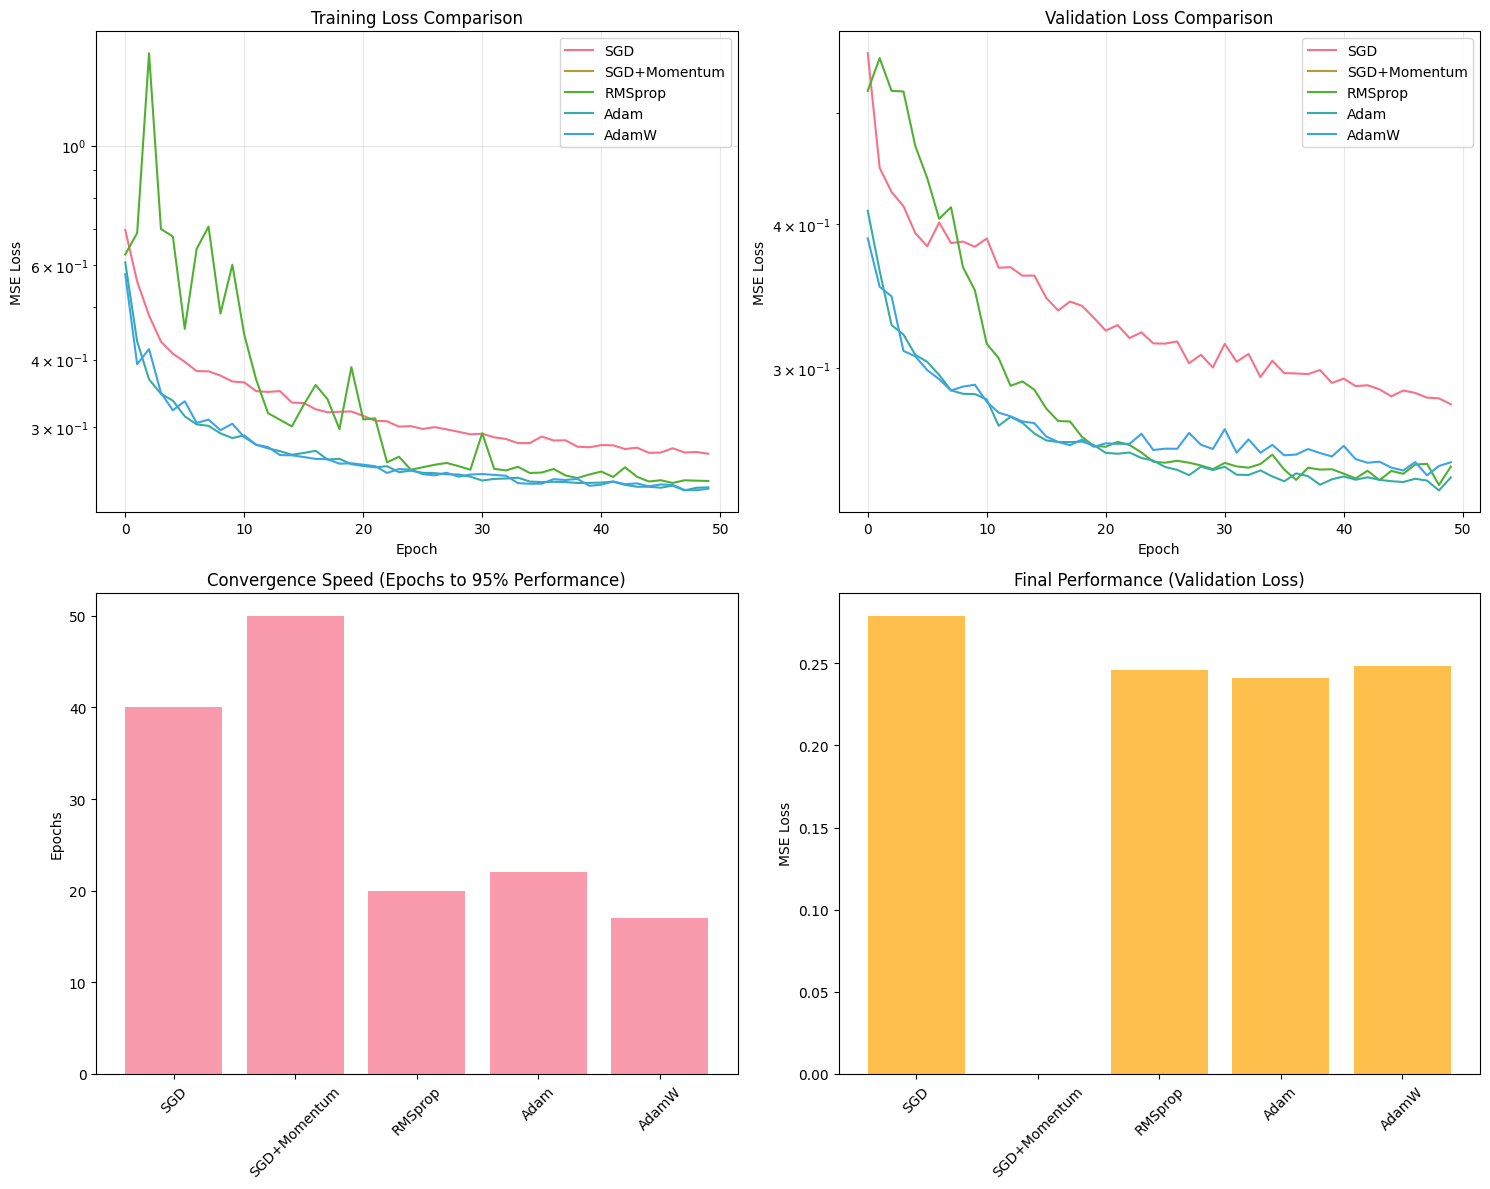

In [8]:

# =============================================================================
# PART 7: ADVANCED OPTIMIZATION
# =============================================================================

print("\n" + "="*60)
print("PART 7: ADVANCED OPTIMIZATION")
print("="*60)

print("7.1 Optimizer Comparison on Real Dataset")

# Use California housing for regression
housing_data = fetch_california_housing()
X_housing = housing_data.data
y_housing = housing_data.target

# Standardize data
scaler_X_housing = StandardScaler()
scaler_y_housing = StandardScaler()
X_housing_scaled = scaler_X_housing.fit_transform(X_housing)
y_housing_scaled = scaler_y_housing.fit_transform(y_housing.reshape(-1, 1)).ravel()

# Split data
X_train_house, X_test_house, y_train_house, y_test_house = train_test_split(
    X_housing_scaled, y_housing_scaled, test_size=0.2, random_state=42)

# Create model for optimizer comparison
def create_regression_model(optimizer):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_dim=X_housing.shape[1]),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# Compare different optimizers
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.01),
    'SGD+Momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
    'AdamW': keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01)
}

optimizer_histories = {}

print("Training models with different optimizers...")
for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    
    model = create_regression_model(optimizer)
    
    history = model.fit(X_train_house, y_train_house,
                       batch_size=32,
                       epochs=50,
                       validation_split=0.2,
                       verbose=0)
    
    optimizer_histories[name] = history.history
    
    # Evaluate
    test_loss, test_mae = model.evaluate(X_test_house, y_test_house, verbose=0)
    print(f"  Test MAE: {test_mae:.4f}")

# Visualize optimizer comparison
print("\n7.2 Optimizer Performance Analysis")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training loss
for name, history in optimizer_histories.items():
    axes[0, 0].plot(history['loss'], label=name)
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Validation loss
for name, history in optimizer_histories.items():
    axes[0, 1].plot(history['val_loss'], label=name)
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_yscale('log')

# Convergence analysis
convergence_epochs = []
final_losses = []
optimizer_names = list(optimizer_histories.keys())

for name in optimizer_names:
    val_loss = np.array(optimizer_histories[name]['val_loss'])
    final_loss = val_loss[-1]
    
    # Find convergence epoch (when loss stabilizes)
    target_loss = final_loss * 1.05
    convergence_epoch = len(val_loss)
    for i, loss in enumerate(val_loss):
        if loss <= target_loss:
            convergence_epoch = i + 1
            break
    
    convergence_epochs.append(convergence_epoch)
    final_losses.append(final_loss)

axes[1, 0].bar(optimizer_names, convergence_epochs, alpha=0.7)
axes[1, 0].set_title('Convergence Speed (Epochs to 95% Performance)')
axes[1, 0].set_ylabel('Epochs')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(optimizer_names, final_losses, alpha=0.7, color='orange')
axes[1, 1].set_title('Final Performance (Validation Loss)')
axes[1, 1].set_ylabel('MSE Loss')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




PART 8: REGULARIZATION TECHNIQUES
8.1 Comprehensive Regularization Analysis
8.2 Training Models with Different Regularization Techniques
Training Baseline model...
  Test MAE: 0.3115, Test MSE: 0.2208
Training L2_Regularization model...
  Test MAE: 0.3293, Test MSE: 0.2915
Training Dropout model...
  Test MAE: 0.3093, Test MSE: 0.2030
Training Batch_Normalization model...
  Test MAE: 0.4640, Test MSE: 0.4521
Training Combined model...
  Test MAE: 0.4465, Test MSE: 0.4889

8.3 Regularization Effects Analysis
8.4 L2 Regularization Strength Analysis


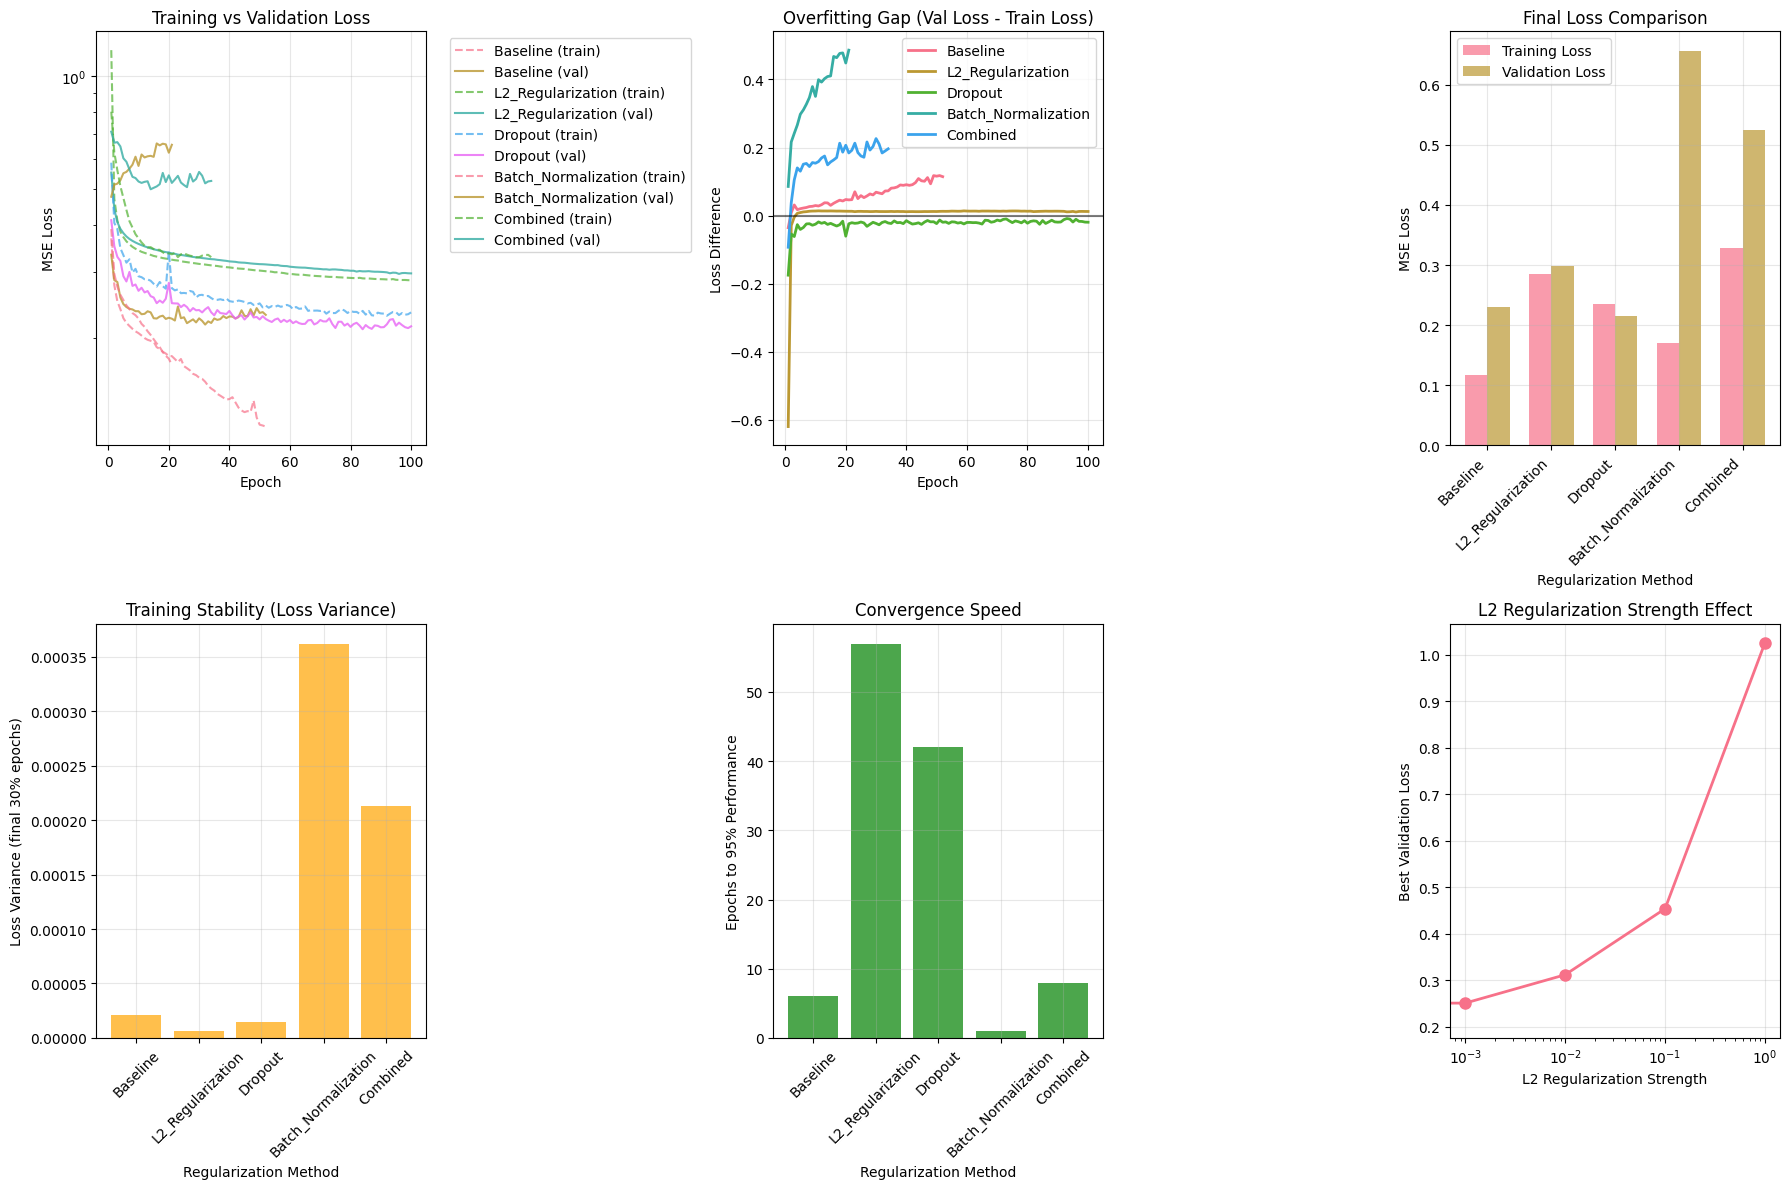

In [9]:

# =============================================================================
# PART 8: REGULARIZATION TECHNIQUES
# =============================================================================

print("\n" + "="*60)
print("PART 8: REGULARIZATION TECHNIQUES")
print("="*60)

print("8.1 Comprehensive Regularization Analysis")

# Create models with different regularization techniques
def create_regularized_models(input_dim):
    """Create models with various regularization techniques"""
    
    models = {}
    
    # No regularization (baseline)
    models['Baseline'] = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    
    # L2 regularization
    models['L2_Regularization'] = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim,
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(64, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(32, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(1)
    ])
    
    # Dropout regularization
    models['Dropout'] = keras.Sequential([
        layers.Dense(256, activation='relu', input_dim=input_dim),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    
    # Batch normalization
    models['Batch_Normalization'] = keras.Sequential([
        layers.Dense(256, input_dim=input_dim),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(1)
    ])
    
    # Combined regularization
    models['Combined'] = keras.Sequential([
        layers.Dense(256, input_dim=input_dim,
                    kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(128,
                    kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        layers.Dense(64,
                    kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        layers.Dense(32),
        layers.Activation('relu'),
        layers.Dense(1)
    ])
    
    return models

# Train regularized models
regularized_models = create_regularized_models(X_housing_scaled.shape[1])
reg_histories = {}

print("8.2 Training Models with Different Regularization Techniques")

for name, model in regularized_models.items():
    print(f"Training {name} model...")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    early_stopping_reg = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    
    history = model.fit(
        X_train_house, y_train_house,
        batch_size=32,
        epochs=100,
        validation_split=0.2,
        callbacks=[early_stopping_reg],
        verbose=0
    )
    
    reg_histories[name] = history.history
    
    # Evaluate
    test_loss, test_mae = model.evaluate(X_test_house, y_test_house, verbose=0)
    print(f"  Test MAE: {test_mae:.4f}, Test MSE: {test_loss:.4f}")

# Visualize regularization effects
print("\n8.3 Regularization Effects Analysis")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Training vs validation loss
for name, history in reg_histories.items():
    epochs = range(1, len(history['loss']) + 1)
    axes[0, 0].plot(epochs, history['loss'], '--', alpha=0.7, label=f'{name} (train)')
    axes[0, 0].plot(epochs, history['val_loss'], '-', alpha=0.8, label=f'{name} (val)')

axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# Overfitting gap analysis
for name, history in reg_histories.items():
    train_loss = np.array(history['loss'])
    val_loss = np.array(history['val_loss'])
    gap = val_loss - train_loss
    epochs = range(1, len(gap) + 1)
    axes[0, 1].plot(epochs, gap, label=name, linewidth=2)

axes[0, 1].set_title('Overfitting Gap (Val Loss - Train Loss)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss Difference')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Final performance comparison
model_names = list(reg_histories.keys())
final_train_loss = [reg_histories[name]['loss'][-1] for name in model_names]
final_val_loss = [reg_histories[name]['val_loss'][-1] for name in model_names]

x_pos = np.arange(len(model_names))
width = 0.35

bars1 = axes[0, 2].bar(x_pos - width/2, final_train_loss, width, 
                      label='Training Loss', alpha=0.7)
bars2 = axes[0, 2].bar(x_pos + width/2, final_val_loss, width, 
                      label='Validation Loss', alpha=0.7)

axes[0, 2].set_title('Final Loss Comparison')
axes[0, 2].set_xlabel('Regularization Method')
axes[0, 2].set_ylabel('MSE Loss')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Training stability (loss variance)
loss_variances = []
for name in model_names:
    val_loss = reg_histories[name]['val_loss']
    stable_period = val_loss[int(0.7 * len(val_loss)):]  # Last 30% of training
    variance = np.var(stable_period) if len(stable_period) > 1 else 0
    loss_variances.append(variance)

axes[1, 0].bar(model_names, loss_variances, alpha=0.7, color='orange')
axes[1, 0].set_title('Training Stability (Loss Variance)')
axes[1, 0].set_xlabel('Regularization Method')
axes[1, 0].set_ylabel('Loss Variance (final 30% epochs)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Convergence speed
convergence_epochs_reg = []
for name in model_names:
    val_loss = np.array(reg_histories[name]['val_loss'])
    final_loss = val_loss[-1]
    target_loss = final_loss * 1.05  # 95% of final performance
    
    convergence_epoch = len(val_loss)  # Default to full training
    for i, loss in enumerate(val_loss):
        if loss <= target_loss:
            convergence_epoch = i + 1
            break
    convergence_epochs_reg.append(convergence_epoch)

axes[1, 1].bar(model_names, convergence_epochs_reg, alpha=0.7, color='green')
axes[1, 1].set_title('Convergence Speed')
axes[1, 1].set_xlabel('Regularization Method')
axes[1, 1].set_ylabel('Epochs to 95% Performance')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

# Regularization strength effect
print("8.4 L2 Regularization Strength Analysis")
regularization_strengths = [0.0, 0.001, 0.01, 0.1, 1.0]
l2_performance = []

for strength in regularization_strengths:
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=X_housing_scaled.shape[1],
                    kernel_regularizer=keras.regularizers.l2(strength)),
        layers.Dense(64, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(strength)),
        layers.Dense(32, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(strength)),
        layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    history = model.fit(X_train_house, y_train_house,
                       validation_split=0.2,
                       epochs=30,
                       verbose=0)
    
    final_val_loss = min(history.history['val_loss'])
    l2_performance.append(final_val_loss)

axes[1, 2].plot(regularization_strengths, l2_performance, 'o-', linewidth=2, markersize=8)
axes[1, 2].set_title('L2 Regularization Strength Effect')
axes[1, 2].set_xlabel('L2 Regularization Strength')
axes[1, 2].set_ylabel('Best Validation Loss')
axes[1, 2].set_xscale('log')
axes[1, 2].grid(True, alpha=0.3)

# Annotate optimal strength
optimal_idx = np.argmin(l2_performance)
optimal_strength = regularization_strengths[optimal_idx]
axes[1, 2].annotate(f'Optimal: {optimal_strength}', 
                   xy=(optimal_strength, l2_performance[optimal_idx]),
                   xytext=(10, 10), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()



In [10]:

# =============================================================================
# FINAL SUMMARY AND COMPREHENSIVE ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("SESSION 4 TUTORIAL SUMMARY")
print("="*70)

print("""
NEURAL NETWORK FUNDAMENTALS:
✓ Perceptrons solve linearly separable problems
✓ MLPs can solve any classification problem (Universal Approximation)
✓ Non-linear activations are essential for complex patterns

BACKPROPAGATION ALGORITHM:
✓ Chain rule enables efficient gradient computation
✓ Forward pass computes predictions
✓ Backward pass computes gradients and updates weights
✓ Proper initialization and gradient clipping prevent numerical issues

ACTIVATION FUNCTIONS:
✓ ReLU solves vanishing gradient problem
✓ Sigmoid useful for output layers (probabilities)
✓ Tanh is zero-centered (better than sigmoid)

DEEP LEARNING ARCHITECTURES:
✓ CNNs excel at spatial pattern recognition (images)
✓ RNNs handle sequential data (time series, text)
✓ LSTMs/GRUs solve vanishing gradients in sequences
✓ Architecture choice depends on data structure


OPTIMIZATION AND TRAINING:
✓ Adam generally performs well across tasks
✓ SGD with momentum for fine-tuning
✓ Learning rate scheduling improves convergence
✓ Early stopping prevents overfitting

REGULARIZATION TECHNIQUES:
✓ Dropout prevents co-adaptation of neurons
✓ Batch normalization stabilizes training
✓ L2 regularization promotes smooth functions


""")


SESSION 4 TUTORIAL SUMMARY

NEURAL NETWORK FUNDAMENTALS:
✓ Perceptrons solve linearly separable problems
✓ MLPs can solve any classification problem (Universal Approximation)
✓ Non-linear activations are essential for complex patterns

BACKPROPAGATION ALGORITHM:
✓ Chain rule enables efficient gradient computation
✓ Forward pass computes predictions
✓ Backward pass computes gradients and updates weights
✓ Proper initialization and gradient clipping prevent numerical issues

ACTIVATION FUNCTIONS:
✓ ReLU solves vanishing gradient problem
✓ Sigmoid useful for output layers (probabilities)
✓ Tanh is zero-centered (better than sigmoid)

DEEP LEARNING ARCHITECTURES:
✓ CNNs excel at spatial pattern recognition (images)
✓ RNNs handle sequential data (time series, text)
✓ LSTMs/GRUs solve vanishing gradients in sequences
✓ Architecture choice depends on data structure


OPTIMIZATION AND TRAINING:
✓ Adam generally performs well across tasks
✓ SGD with momentum for fine-tuning
✓ Learning rate sch